Shape: (300, 4)
       pengalaman     edu    gaji
count      300.00  300.00  300.00
mean         9.90    0.89   27.40
std          5.89    0.83   13.41
min          0.10    0.00    1.67
25%          4.78    0.00   16.24
50%         10.23    1.00   27.97
75%         15.14    2.00   38.89
max         19.80    2.00   54.22


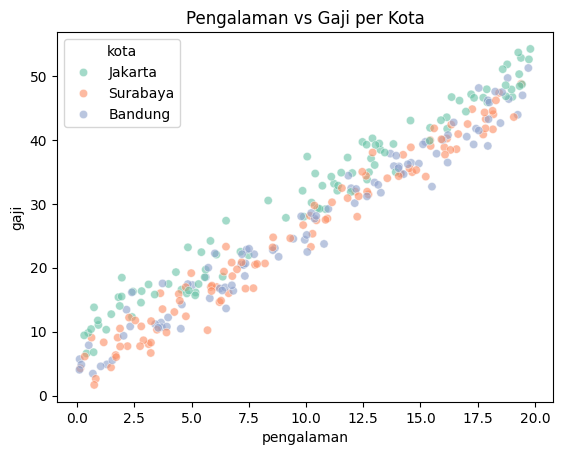

Kolom setelah encoding: ['pengalaman', 'edu', 'gaji', 'kota_Jakarta', 'kota_Surabaya']
Train: 240 baris, Test: 60 baris
β0 (intercept): 27.514

        Fitur  Koefisien
   pengalaman     13.042
 kota_Jakarta      1.837
          edu      1.188
kota_Surabaya     -0.292
=== Metrik Evaluasi ===
MAE = 1.649 juta rupiah
RMSE = 4.507 juta rupiah
R2 = 0.9740 (97.4% variasi dijelaskan)
Selisih RMSE-MAE = 2.857


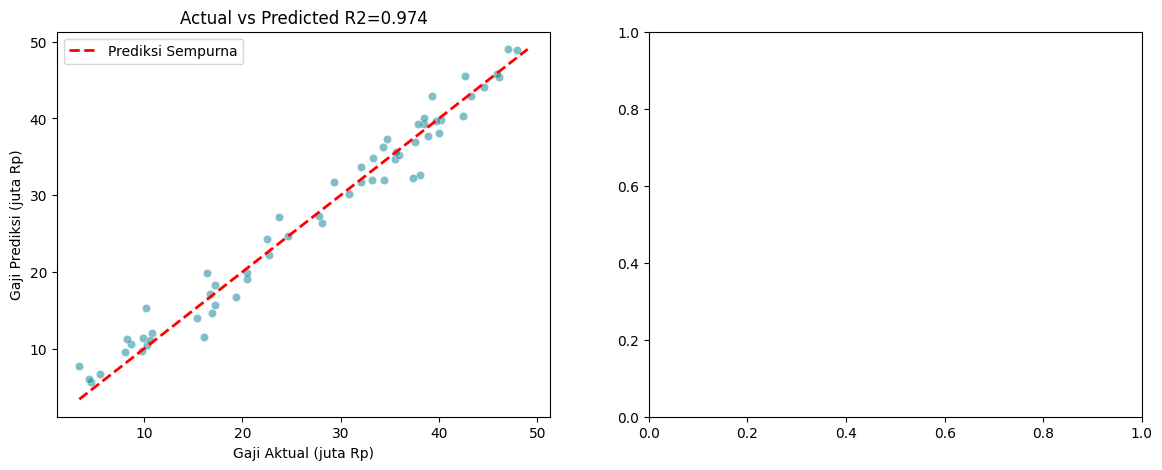

In [14]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (mean_squared_error, r2_score, mean_absolute_error)

# Generate dataset sintesis
np.random.seed(42); n = 300
pengalaman = np.random.uniform(0, 20, n)
edu = np.random.choice([0,1,2], n) # SMA=0, D3=1, S1-2
kota = np.random.choice(['Jakarta', 'Surabaya', 'Bandung'], n)
gaji = (3.0 + 2.2*pengalaman + 1.5*edu
        + np.where(kota=='Jakarta', 4.0, 0)
        + np.random.normal(0,2,n))

df = pd.DataFrame({'pengalaman':pengalaman, 'edu':edu, 'kota':kota, 'gaji':gaji})

# EDA singkat
print('Shape:', df.shape)
print(df.describe().round(2))

# Scatter: pengalaman vs gaji
sns.scatterplot(data=df, x='pengalaman', y='gaji', hue='kota', palette='Set2', alpha=0.6)
plt.title('Pengalaman vs Gaji per Kota')
plt.show()

# One-Hot Encoding kolom 'kota'
df = pd.get_dummies(df, columns=['kota'], drop_first=True, dtype=int)
print('Kolom setelah encoding:', df.columns.tolist())

# Pisahkan fitur dan target
X = df.drop('gaji', axis=1)
y = df['gaji']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {X_train.shape[0]} baris, Test: {X_test.shape[0]} baris')

# StandardScaler - fit pada training set saja
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_s, y_train)

# Tampilkan koefisien
print(f'β0 (intercept): {model.intercept_:.3f}')
print()
coef_df = pd.DataFrame({'Fitur': X.columns, 'Koefisien': model.coef_.round(3)}).sort_values('Koefisien', ascending=False)
print(coef_df.to_string(index=False))

# Interpretasi: fitur mana yang paling berpengaruh?
# Koefisien positif -> gaji naik
# Koefisien negatif -> gaji turun

y_pred = model.predict(X_test_s)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('=== Metrik Evaluasi ===')
print(f'MAE = {mae:.3f} juta rupiah')
print(f'RMSE = {rmse:.3f} juta rupiah')
print(f'R2 = {r2:.4f} ({r2*100:.1f}% variasi dijelaskan)')
print(f'Selisih RMSE-MAE = {rmse-mae:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Plot 1: Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.5, color='#028090', edgecolors='white', lw=0.5)
lims = [min(y_test.min(), y_pred.min()),
        max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', lw=2, label='Prediksi Sempurna')
axes[0].set_xlabel('Gaji Aktual (juta Rp)')
axes[0].set_ylabel('Gaji Prediksi (juta Rp)')
axes[0].set_title(f'Actual vs Predicted R2={r2:.3f}')
axes[0].legend()

In [15]:
# Berapa rata-rata kesalahan prediksi dalam rupiah?
print(f'Rata-rata kesalahan prediksi dalam rupiah (MAE) adalah {mae:.3f} juta rupiah')

# Apakah R2 cukup baik untuk kasus ini?
print(f'R2 sebesar {r2:.4f} ({r2*100:.1f}% variasi dijelaskan) menunjukkan bahwa model memiliki kemampuan prediksi yang sangat baik, karena sebagian besar variasi gaji dapat dijelaskan oleh fitur-fitur yang digunakan.')

# Apakah ada indikasi outlier?
print('Dari plot Actual vs Predicted, titik-titik terlihat tersebar cukup rapat di sekitar garis prediksi sempura, menunjukkan tidak ada indikasi outlier yang siginifikan.')

Rata-rata kesalahan prediksi dalam rupiah (MAE) adalah 1.649 juta rupiah
R2 sebesar 0.9740 (97.4% variasi dijelaskan) menunjukkan bahwa model memiliki kemampuan prediksi yang sangat baik, karena sebagian besar variasi gaji dapat dijelaskan oleh fitur-fitur yang digunakan.
Dari plot Actual vs Predicted, titik-titik terlihat tersebar cukup rapat di sekitar garis prediksi sempura, menunjukkan tidak ada indikasi outlier yang siginifikan.
